In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset

df = pd.read_csv('Unemployment in India.csv')

# Display first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [4]:
# Check number of rows and columns

df.shape

(768, 7)

In [5]:
# Check missing values in dataset

df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [6]:
# Clean column names

df.columns = df.columns.str.strip()

# Display cleaned column names
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [7]:
# Convert Date column to datetime format

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Check first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [8]:
# Statistical summary of numerical columns

df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [9]:
# Check unique regions/states

df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', nan, 'Chandigarh'],
      dtype=object)

In [10]:
# Count Rural and Urban values

df['Area'].value_counts()

Area
Urban    381
Rural    359
Name: count, dtype: int64

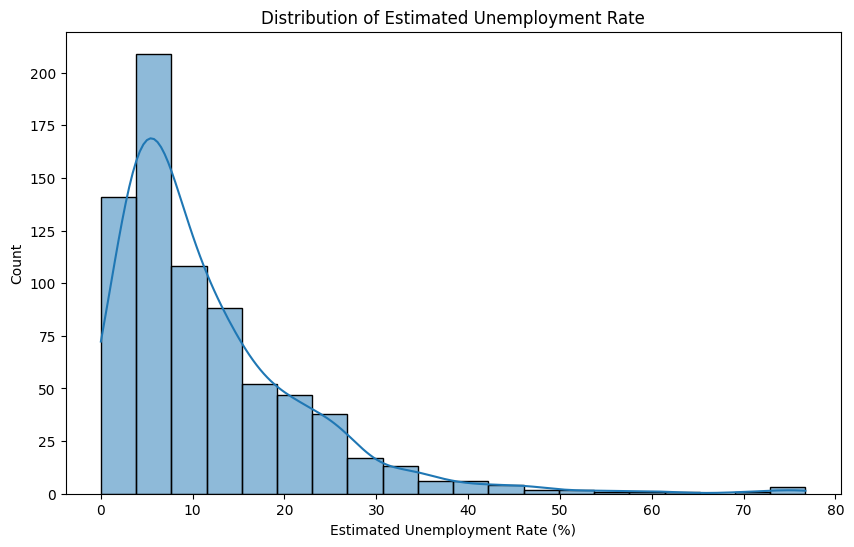

In [11]:
# Overall unemployment rate distribution

plt.figure(figsize=(10, 6))
sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20, kde=True)
plt.title('Distribution of Estimated Unemployment Rate')
plt.xlabel('Estimated Unemployment Rate (%)')
plt.ylabel('Count')
plt.show()

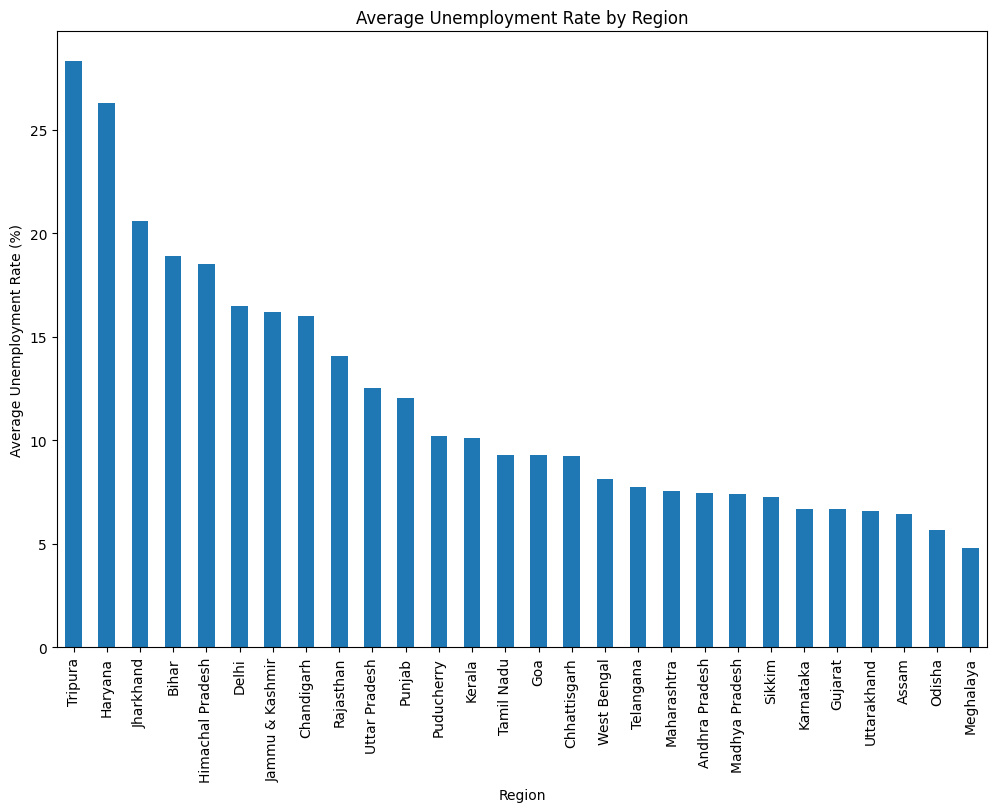

In [12]:
# Average unemployment rate by region

region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
region_unemployment.plot(kind='bar')
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.show()

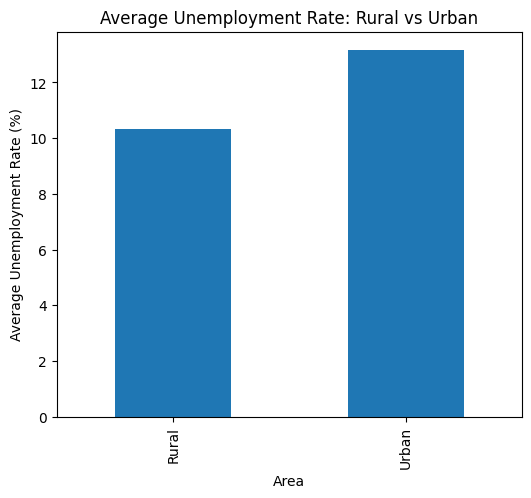

In [13]:
# Average unemployment rate by area

area_unemployment = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(6, 5))
area_unemployment.plot(kind='bar')
plt.title('Average Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Average Unemployment Rate (%)')
plt.show()

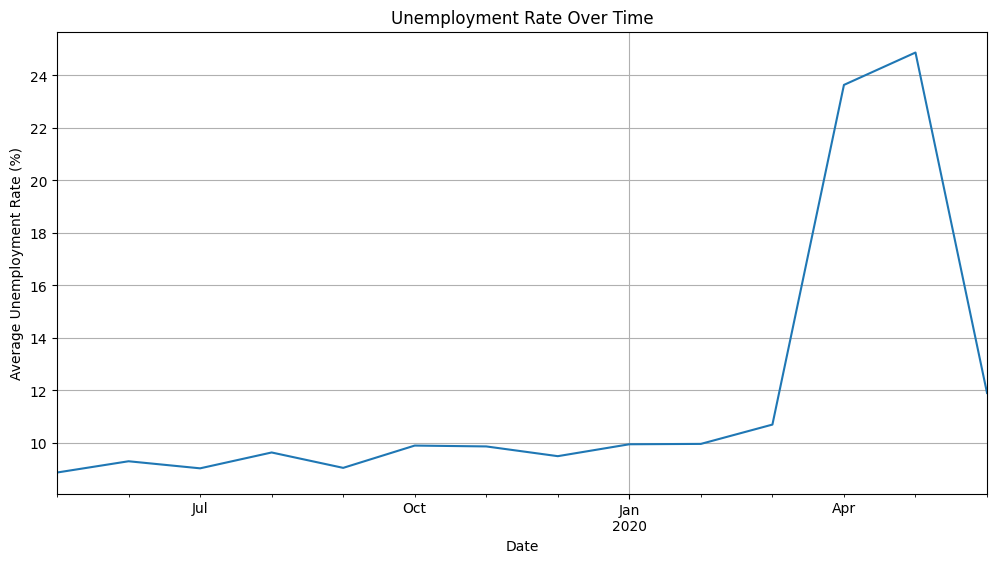

In [14]:
# Unemployment rate over time

date_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12, 6))
date_unemployment.plot()
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(True)
plt.show()

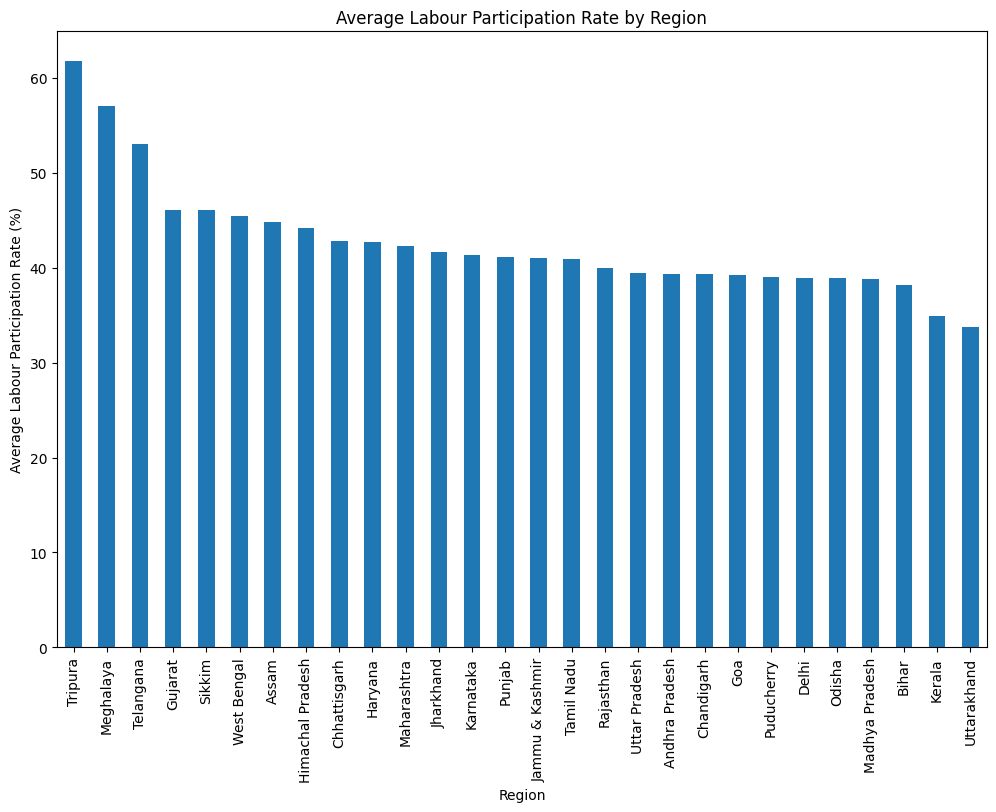

In [17]:
# Average labour participation rate by region

labour_rate = df.groupby('Region')['Estimated Labour Participation Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
labour_rate.plot(kind='bar')
plt.title('Average Labour Participation Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Labour Participation Rate (%)')
plt.xticks(rotation=90)
plt.show()

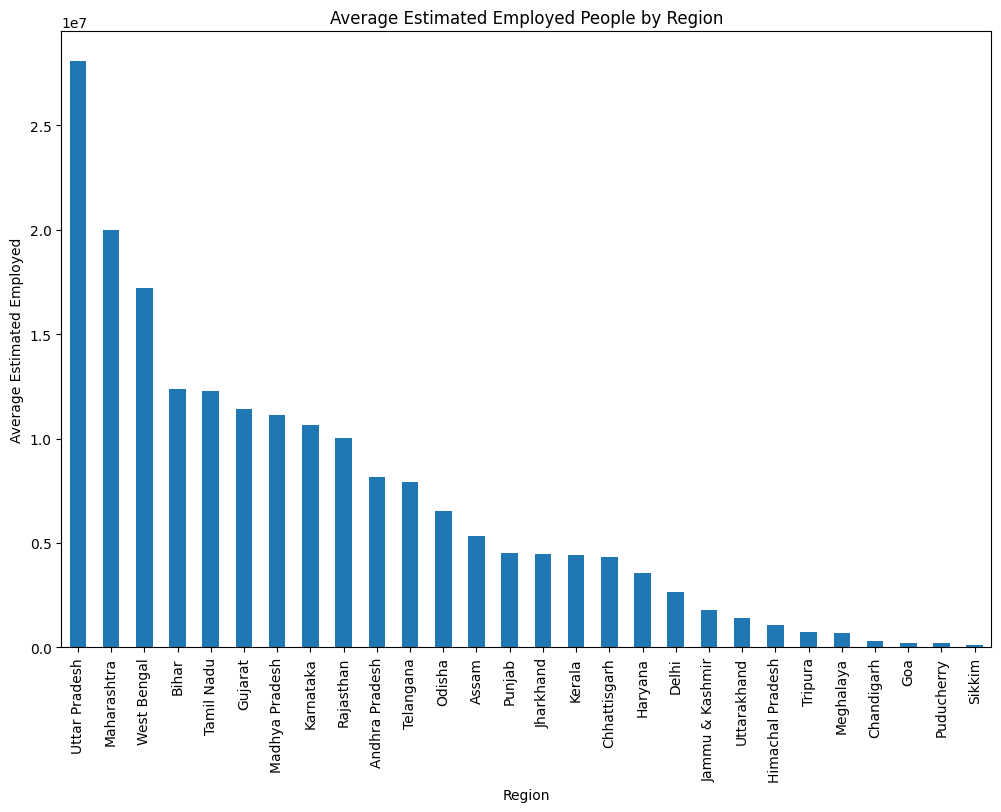

In [18]:
# Average estimated employed people by region

employment_region = df.groupby('Region')['Estimated Employed'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
employment_region.plot(kind='bar')
plt.title('Average Estimated Employed People by Region')
plt.xlabel('Region')
plt.ylabel('Average Estimated Employed')
plt.xticks(rotation=90)
plt.show()

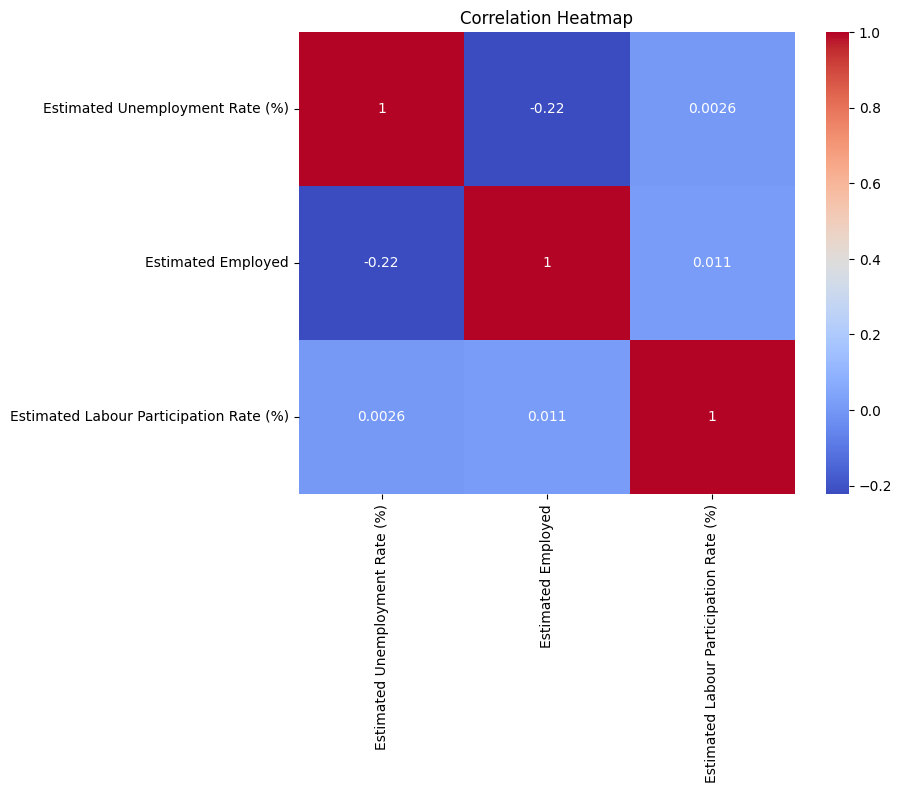

In [19]:
# Correlation heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()